In [1]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt

##### Data Cleaning

In [2]:
all_UF_df = pd.read_csv("UF_date_updated.csv")

In [3]:
all_UF_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'City', 'State', 'Country', 'Shape',
       'Duration', 'Summary', 'Posted', 'Images', 'Year Full',
       'Updated Date/Time'],
      dtype='object')

In [4]:
all_UF_df['Updated Date/Time']

0         2023-07-29 17:45:00
1         2023-07-29 11:20:00
2         2023-07-29 02:30:00
3         2023-07-29 00:20:00
4         2023-07-28 23:05:00
                 ...         
145173    1860-08-02 23:00:00
145174    1800-04-05 20:00:00
145175    1790-06-30 21:00:00
145176    1762-12-11 21:00:00
145177    1721-02-01 05:24:00
Name: Updated Date/Time, Length: 145178, dtype: object

In [5]:
column_to_delete = 'Unnamed: 0'
all_UF_df = all_UF_df.drop(column_to_delete, axis = 1)

In [7]:
all_UF_df.shape

(145178, 11)

In [8]:
all_UF_df.columns

Index(['Unnamed: 0.1', 'City', 'State', 'Country', 'Shape', 'Duration',
       'Summary', 'Posted', 'Images', 'Year Full', 'Updated Date/Time'],
      dtype='object')

In [9]:
column_to_delete = 'Unnamed: 0.1'
all_UF_df = all_UF_df.drop(column_to_delete, axis = 1)

In [10]:
all_UF_df.columns

Index(['City', 'State', 'Country', 'Shape', 'Duration', 'Summary', 'Posted',
       'Images', 'Year Full', 'Updated Date/Time'],
      dtype='object')

In [11]:
all_UF_df['State'] = all_UF_df['State'].str.upper()
all_UF_df['Country'] = all_UF_df['Country'].str.upper()
all_UF_df['City'] = all_UF_df['City'].str.upper()

In [12]:
all_UF_df

,City,State,Country,Shape,Duration,Summary,Posted,Images,Year Full,Updated Date/Time
0,MALANG,EAST JAVA,INDONESIA,Light,Still there as at 8:30pm,Green flashing (and moving) lights,7/29/23,NaN,2023,2023-07-29 17:45:00
1,RIVERVIEW,FL,USA,Unknown,11:21,.001/ 9 screen shot clip of fly by,7/29/23,Yes,2023,2023-07-29 11:20:00
2,MALLUSK,ANTRIM AND NEWTOWNABBEY,UNITED KINGDOM,Triangle,still current,A very bright light which moved closer. On the...,7/29/23,Yes,2023,2023-07-29 02:30:00
3,WORKSOP,NOTTINGHAMSHIRE,UNITED KINGDOM,Disk,Around a minute.,Flying saucer with red lights.,7/29/23,NaN,2023,2023-07-29 00:20:00
4,GAINESVILLE,FL,USA,Light,No more than 10 seconds,After observing a Space X launch from 100+ mil...,7/29/23,NaN,2023,2023-07-28 23:05:00
...,...,...,...,...,...,...,...,...,...,...
145173,CHEROKEE,NC,USA,Fireball,less than a minute?,meteor or fireball passage,12/2/00,NaN,1860,1860-08-02 23:00:00
145174,BATON ROUGE,LA,USA,Light,15 seconds,UFO report communicated by Thomas Jefferson,2/8/11,NaN,1800,1800-04-05 20:00:00
145175,CARLISLE,NY,USA,Fireball,less than 1 minute,"Slow Moving Fireball, stench of burning sulpher.",8/7/07,NaN,1790,1790-06-30 21:00:00
145176,"LULWORTH, DORSETSHIRE (NEAR) (UK/ENGLAND)",NaN,UNITED KINGDOM,NaN,>1 minute,Reported in a London paper in 1762: a bright l...,5/15/06,NaN,1762,1762-12-11 21:00:00


In [13]:
usa_ufo = all_UF_df[all_UF_df['Country'].isin(['USA'])]
not_usa = all_UF_df[~all_UF_df['Country'].isin(['USA'])]

In [14]:
usa_ufo

,City,State,Country,Shape,Duration,Summary,Posted,Images,Year Full,Updated Date/Time
1,RIVERVIEW,FL,USA,Unknown,11:21,.001/ 9 screen shot clip of fly by,7/29/23,Yes,2023,2023-07-29 11:20:00
4,GAINESVILLE,FL,USA,Light,No more than 10 seconds,After observing a Space X launch from 100+ mil...,7/29/23,NaN,2023,2023-07-28 23:05:00
5,LEESBURG,FL,USA,Orb,0:45,A Big Bright Orange Redish Ball / Orb Was Hove...,7/29/23,NaN,2023,2023-07-28 23:05:00
6,NORTHVALE,NJ,USA,Changing,20 minutes or more,Observed light moving in manner not consistent...,7/29/23,NaN,2023,2023-07-28 21:40:00
8,SIOUX FALLS,SD,USA,Light,5 minutes,Light was there and gone.,7/29/23,NaN,2023,2023-07-28 04:25:00
...,...,...,...,...,...,...,...,...,...,...
145172,NEW YORK CITY (MANHATTAN),NY,USA,Cross,unknown,"Strange, cross-shaped, object witnessed over N...",2/4/13,NaN,1861,1861-03-29 00:00:00
145173,CHEROKEE,NC,USA,Fireball,less than a minute?,meteor or fireball passage,12/2/00,NaN,1860,1860-08-02 23:00:00
145174,BATON ROUGE,LA,USA,Light,15 seconds,UFO report communicated by Thomas Jefferson,2/8/11,NaN,1800,1800-04-05 20:00:00
145175,CARLISLE,NY,USA,Fireball,less than 1 minute,"Slow Moving Fireball, stench of burning sulpher.",8/7/07,NaN,1790,1790-06-30 21:00:00


In [15]:
not_usa['Country'].unique()

array(['INDONESIA', 'UNITED KINGDOM', 'NICARAGUA', 'PORTUGAL', 'IRAN',
       'MOROCCO', 'THAILAND', 'GERMANY', 'CANADA',
       'TURKS AND CAICOS ISLANDS', 'INTERNATIONAL WATERS', 'AUSTRALIA',
       'SWEDEN', '0', 'SPAIN', 'INDIA', 'FINLAND', 'KENYA', 'IRAQ',
       'COLOMBIA', 'IRELAND', 'JORDAN', 'KYRGYZSTAN', 'CHINA', 'MALTA',
       'ARUBA', 'NEW ZEALAND', 'SWITZERLAND', 'SOUTH AFRICA', 'ROMANIA',
       'ARGENTINA', 'JAMAICA', 'TURKEY', 'UNITED KINGDON',
       'AMERICAN SAMOA', 'MEXICO', nan,
       'UNITED STATES MINOR OUTLYING ISLANDS', 'EGYPT', 'GHANA', 'ISRAEL',
       'NETHERLANDS THE', 'ITALY', 'AUSTRIA', 'HUNGARY', 'CHAD', 'CUBA',
       'FIJI ISLANDS', 'SAINT KITTS AND NEVIS', 'CYPRUS', 'BELGIUM',
       'EAST TIMOR', 'FRANCE', 'PHILIPPINES', 'PARAGUAY', 'BARBADOS',
       'POLAND', 'JAPAN', 'DOMINICAN REPUBLIC', 'ETHIOPIA', 'BULGARIA',
       'PUERTO RICO', 'ALGERIA', 'VIETNAM', 'BOSNIA AND HERZEGOVINA',
       'BERMUDA', 'NORWAY', 'HONG KONG S.A.R.', 'UNITED ARAB EMIR

In [18]:
specific_1 = not_usa[not_usa['Country'] == 'COLORADO SPRINGS']
print(specific_1)

                             City State           Country   Shape Duration  \
11521  COLORADO SPRINGS, COLORADO    CO  COLORADO SPRINGS  Circle     6:40   

                                                 Summary    Posted Images  \
11521  It was moving then at the end I tried to track...  12/23/20    NaN   

       Year Full    Updated Date/Time  
11521       2020  2020-11-20 06:30:00  


In [20]:
specific_2 = not_usa[not_usa['Country'] == '0']
print(specific_2)

                      City State Country     Shape    Duration  \
188  ISLAND PARK RESERVOIR    NV       0  Changing  15 minutes   

                                               Summary   Posted Images  \
188  Cluster of lights varying in speed and moving ...  7/29/23    NaN   

     Year Full    Updated Date/Time  
188       2023  2023-07-13 23:00:00  


In [21]:
specific_3 = not_usa[not_usa['Country'] == 'U. S. VIRGIN ISLANDS']
print(specific_3)

                                                     City State  \
54303                   ST. THOMAS (U. S. VIRGIN ISLANDS)   NaN   
65485                    KINGSHILL (U. S. VIRGIN ISLANDS)   NaN   
129760                  ST. THOMAS (U. S. VIRGIN ISLANDS)   NaN   
130771                 ST. THOMAS, (U. S. VIRGIN ISLANDS)    VI   
133264  ST. THOMAS (CHARLOTTE AMALIE) (U. S. VIRGIN IS...   NaN   
138544                   ST. CROIX (U. S. VIRGIN ISLANDS)   NaN   
140135                   ST.THOMAS (U. S. VIRGIN ISLANDS)   NaN   

                     Country     Shape     Duration  \
54303   U. S. VIRGIN ISLANDS  Cylinder    2 minutes   
65485   U. S. VIRGIN ISLANDS  Fireball    3 seconds   
129760  U. S. VIRGIN ISLANDS       NaN     not sure   
130771  U. S. VIRGIN ISLANDS       Orb    5-8 SECDS   
133264  U. S. VIRGIN ISLANDS    Circle      UNKNOWN   
138544  U. S. VIRGIN ISLANDS     Light    5 minutes   
140135  U. S. VIRGIN ISLANDS      Disk  130 seconds   

                      

In [22]:
specific_4 = not_usa[not_usa['Country'] == 'U. S. VIRGIN ISLANDS']
print(specific_4)

                                                     City State  \
54303                   ST. THOMAS (U. S. VIRGIN ISLANDS)   NaN   
65485                    KINGSHILL (U. S. VIRGIN ISLANDS)   NaN   
129760                  ST. THOMAS (U. S. VIRGIN ISLANDS)   NaN   
130771                 ST. THOMAS, (U. S. VIRGIN ISLANDS)    VI   
133264  ST. THOMAS (CHARLOTTE AMALIE) (U. S. VIRGIN IS...   NaN   
138544                   ST. CROIX (U. S. VIRGIN ISLANDS)   NaN   
140135                   ST.THOMAS (U. S. VIRGIN ISLANDS)   NaN   

                     Country     Shape     Duration  \
54303   U. S. VIRGIN ISLANDS  Cylinder    2 minutes   
65485   U. S. VIRGIN ISLANDS  Fireball    3 seconds   
129760  U. S. VIRGIN ISLANDS       NaN     not sure   
130771  U. S. VIRGIN ISLANDS       Orb    5-8 SECDS   
133264  U. S. VIRGIN ISLANDS    Circle      UNKNOWN   
138544  U. S. VIRGIN ISLANDS     Light    5 minutes   
140135  U. S. VIRGIN ISLANDS      Disk  130 seconds   

                      

In [23]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' '0K'
 'KS' 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'QUINTANA ROO'
 'ON' 'AMERICAN SAMOA' 'PR' 'UNITED STATES VIRGIN ISLANDS' 'MB' 'CORNWALL'
 'M0' 'WORCESTERSHIRE' 'OKINAWA PREFECTURE' 'SK' 'NB' 'SOUTH CAROLINA'
 'NS' 'BC' 'AB' 'WASHINGTON, DC' 'ONTARIO' 'GUAM']


In [24]:
#filter to see 0K
rows_with_state_0K = usa_ufo[usa_ufo['State'] == '0K']

print(rows_with_state_0K)

         City State Country Shape               Duration  \
248  SKIATOOK    0K     USA   Orb  Little over 5 seconds   

                            Summary   Posted Images  Year Full  \
248  Two Orbs Rushed Across the Sky  7/29/23    NaN       2023   

       Updated Date/Time  
248  2023-07-10 00:10:00  


In [25]:
#replace 0K with OK
usa_ufo['State'].replace('0K', 'OK', inplace=True)
print(usa_ufo['State'])

1         FL
4         FL
5         FL
6         NJ
8         SD
          ..
145172    NY
145173    NC
145174    LA
145175    NY
145177    CA
Name: State, Length: 129278, dtype: object


/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/98184319.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usa_ufo['State'].replace('0K', 'OK', inplace=True)


In [26]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'QUINTANA ROO' 'ON'
 'AMERICAN SAMOA' 'PR' 'UNITED STATES VIRGIN ISLANDS' 'MB' 'CORNWALL' 'M0'
 'WORCESTERSHIRE' 'OKINAWA PREFECTURE' 'SK' 'NB' 'SOUTH CAROLINA' 'NS'
 'BC' 'AB' 'WASHINGTON, DC' 'ONTARIO' 'GUAM']


In [27]:
#check'quintana_roo
rows_with_state_QUINTANA_ROO = usa_ufo[usa_ufo['State'] == 'QUINTANA ROO']

print(rows_with_state_QUINTANA_ROO)

        City         State Country  Shape      Duration  \
1833  CANCUN  QUINTANA ROO     USA  Other   1-3 minutes   
6116  CANCUN  QUINTANA ROO     USA   Star  8-10 seconds   

                                                Summary   Posted Images  \
1833                            Round metallic ball UFO   3/6/23    NaN   
6116  Looking at stars, we noticed a shooting star m...  4/22/22    NaN   

      Year Full    Updated Date/Time  
1833       2023  2023-02-07 22:00:00  
6116       2022  2022-04-19 22:30:00  


In [28]:
#filter
usa_ufo = usa_ufo[usa_ufo['State'] != 'QUINTANA ROO']

# Print the updated 'usa_ufo' DataFrame
print(usa_ufo)

                             City State Country     Shape  \
1                       RIVERVIEW    FL     USA   Unknown   
4                     GAINESVILLE    FL     USA     Light   
5                        LEESBURG    FL     USA       Orb   
6                       NORTHVALE    NJ     USA  Changing   
8                     SIOUX FALLS    SD     USA     Light   
...                           ...   ...     ...       ...   
145172  NEW YORK CITY (MANHATTAN)    NY     USA     Cross   
145173                   CHEROKEE    NC     USA  Fireball   
145174                BATON ROUGE    LA     USA     Light   
145175                   CARLISLE    NY     USA  Fireball   
145177              CRESCENT CITY    CA     USA   Unknown   

                       Duration  \
1                         11:21   
4       No more than 10 seconds   
5                          0:45   
6            20 minutes or more   
8                     5 minutes   
...                         ...   
145172                

In [29]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON'
 'AMERICAN SAMOA' 'PR' 'UNITED STATES VIRGIN ISLANDS' 'MB' 'CORNWALL' 'M0'
 'WORCESTERSHIRE' 'OKINAWA PREFECTURE' 'SK' 'NB' 'SOUTH CAROLINA' 'NS'
 'BC' 'AB' 'WASHINGTON, DC' 'ONTARIO' 'GUAM']


In [30]:
#filter M0
rows_with_state_M0 = usa_ufo[usa_ufo['State'] == 'M0']
print(rows_with_state_M0)

           City State Country      Shape     Duration  \
15479  HANNIBAL    M0     USA  Formation  2-3 minutes   

                                                 Summary   Posted Images  \
15479  Line formation of UFOs leaving the atmosphere...  6/25/20    NaN   

       Year Full    Updated Date/Time  
15479       2020  2020-04-26 21:00:00  


In [31]:
#M0 to MO
usa_ufo['State'].replace('M0', 'MO', inplace=True)
print(usa_ufo['State'])

1         FL
4         FL
5         FL
6         NJ
8         SD
          ..
145172    NY
145173    NC
145174    LA
145175    NY
145177    CA
Name: State, Length: 129276, dtype: object


/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/286094986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usa_ufo['State'].replace('M0', 'MO', inplace=True)


In [32]:
#washington, dc to dc
usa_ufo['State'].replace('WASHINGTON, DC', 'DC', inplace=True)

print(usa_ufo['State'])

1         FL
4         FL
5         FL
6         NJ
8         SD
          ..
145172    NY
145173    NC
145174    LA
145175    NY
145177    CA
Name: State, Length: 129276, dtype: object


/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/2378729703.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usa_ufo['State'].replace('WASHINGTON, DC', 'DC', inplace=True)


In [33]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON'
 'AMERICAN SAMOA' 'PR' 'UNITED STATES VIRGIN ISLANDS' 'MB' 'CORNWALL'
 'WORCESTERSHIRE' 'OKINAWA PREFECTURE' 'SK' 'NB' 'SOUTH CAROLINA' 'NS'
 'BC' 'AB' 'ONTARIO' 'GUAM']


In [34]:
rows_with_state_USVI = usa_ufo[usa_ufo['State'] == 'UNITED STATES VIRGIN ISLANDS']

print(rows_with_state_USVI)

                             City                         State Country Shape  \
8073  FREDERIKSTED ST> CROIX USVI  UNITED STATES VIRGIN ISLANDS     USA  Oval   

     Duration                                            Summary    Posted  \
8073      NaN  Noticed an image in a picture when looking at ...  12/19/21   

     Images  Year Full    Updated Date/Time  
8073    Yes       2021  2021-10-26 11:00:00  


In [35]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON'
 'AMERICAN SAMOA' 'PR' 'UNITED STATES VIRGIN ISLANDS' 'MB' 'CORNWALL'
 'WORCESTERSHIRE' 'OKINAWA PREFECTURE' 'SK' 'NB' 'SOUTH CAROLINA' 'NS'
 'BC' 'AB' 'ONTARIO' 'GUAM']


In [36]:
states_to_remove = ['AMERICAN SAMOA', 'PR', 'UNITED STATES VIRGIN ISLANDS',
                   'CORNWALL', 'WORCESTERSHIRE', 'OKINAWA PREFECTURE', 'ONTARIO', 'GUAM']
usa_ufo = usa_ufo[~usa_ufo['State'].isin(states_to_remove)]

print(usa_ufo)

                             City State Country     Shape  \
1                       RIVERVIEW    FL     USA   Unknown   
4                     GAINESVILLE    FL     USA     Light   
5                        LEESBURG    FL     USA       Orb   
6                       NORTHVALE    NJ     USA  Changing   
8                     SIOUX FALLS    SD     USA     Light   
...                           ...   ...     ...       ...   
145172  NEW YORK CITY (MANHATTAN)    NY     USA     Cross   
145173                   CHEROKEE    NC     USA  Fireball   
145174                BATON ROUGE    LA     USA     Light   
145175                   CARLISLE    NY     USA  Fireball   
145177              CRESCENT CITY    CA     USA   Unknown   

                       Duration  \
1                         11:21   
4       No more than 10 seconds   
5                          0:45   
6            20 minutes or more   
8                     5 minutes   
...                         ...   
145172                

In [37]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON' 'MB' 'SK' 'NB'
 'SOUTH CAROLINA' 'NS' 'BC' 'AB']


In [38]:
rows_with_state_SC = usa_ufo[usa_ufo['State'] == 'SOUTH CAROLINA']
print(rows_with_state_SC)

                         City           State Country Shape   Duration  \
31263  FLORIDA COAST (AT SEA)  SOUTH CAROLINA     USA   NaN  <1 second   

                                                 Summary  Posted Images  \
31263  Bright green orb, surrounded by white light, f...  7/7/17    NaN   

       Year Full    Updated Date/Time  
31263       2017  2017-06-26 22:00:00  


In [39]:
usa_ufo['State'].replace('SOUTH CAROLINA', 'SC', inplace=True)
print(usa_ufo['State'])

1         FL
4         FL
5         FL
6         NJ
8         SD
          ..
145172    NY
145173    NC
145174    LA
145175    NY
145177    CA
Name: State, Length: 129268, dtype: object


In [40]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' '0R' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS'
 'ID' 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON' 'MB' 'SK' 'NB'
 'NS' 'BC' 'AB']


In [41]:
#filter
rows_with_state_0R = usa_ufo[usa_ufo['State'] == '0R']
print(rows_with_state_0R)

        City State Country Shape Duration  \
140  CORBETT    0R     USA  Oval  Seconds   

                                               Summary   Posted Images  \
140  I was taking pictures of bald eagle with my ph...  7/29/23    Yes   

     Year Full    Updated Date/Time  
140       2023  2023-07-16 23:20:00  


In [42]:
#0R to OR
usa_ufo['State'].replace('0R', 'OR', inplace=True)
print(usa_ufo['State'])

1         FL
4         FL
5         FL
6         NJ
8         SD
          ..
145172    NY
145173    NC
145174    LA
145175    NY
145177    CA
Name: State, Length: 129268, dtype: object


In [43]:
print(usa_ufo['State'].unique())

['FL' 'NJ' 'SD' 'CA' 'WY' 'NY' 'IN' 'WA' 'WV' 'NV' 'MN' 'AR' 'IA' 'TX'
 'TN' 'NC' 'CT' 'MI' 'OK' 'CO' 'NH' 'GA' 'PA' 'LA' 'VT' 'MA' 'AZ' 'AL'
 'OR' 'OH' 'IL' 'MO' 'SC' 'WI' 'HI' 'DE' 'VA' 'NM' 'MD' 'NE' 'KS' 'ID'
 'MS' 'UT' 'KY' 'RI' nan 'AK' 'MT' 'ME' 'ND' 'DC' 'ON' 'MB' 'SK' 'NB' 'NS'
 'BC' 'AB']


In [44]:
#check for nulls in state
rows_with_nan_state = usa_ufo[usa_ufo['State'].isna()]
print(rows_with_nan_state)

                     City State Country     Shape      Duration  \
399     POOLE TOWN CENTRE   NaN     USA      Oval    45 Seconds   
937          WEST CHESTER   NaN     USA      Oval  7-12 seconds   
950                   NaN   NaN     USA     Other       All day   
954           PUNTA GORDA   NaN     USA    Circle    20 seconds   
1078                  NaN   NaN     USA     Light           NaN   
...                   ...   ...     ...       ...           ...   
142605                NaN   NaN     USA       NaN           NaN   
142744                NaN   NaN     USA  Triangle    3 minutes?   
144402       PHILADELPHIA   NaN     USA    Circle           NaN   
144793        MEXICO CITY   NaN     USA   Unknown           NaN   
145034                NaN   NaN     USA       NaN           NaN   

                                                  Summary    Posted Images  \
399     I noticed two stars close together. One vanish...   7/10/23    NaN   
937     Potential UAP over route 202 or

In [45]:
usa_ufo

,City,State,Country,Shape,Duration,Summary,Posted,Images,Year Full,Updated Date/Time
1,RIVERVIEW,FL,USA,Unknown,11:21,.001/ 9 screen shot clip of fly by,7/29/23,Yes,2023,2023-07-29 11:20:00
4,GAINESVILLE,FL,USA,Light,No more than 10 seconds,After observing a Space X launch from 100+ mil...,7/29/23,NaN,2023,2023-07-28 23:05:00
5,LEESBURG,FL,USA,Orb,0:45,A Big Bright Orange Redish Ball / Orb Was Hove...,7/29/23,NaN,2023,2023-07-28 23:05:00
6,NORTHVALE,NJ,USA,Changing,20 minutes or more,Observed light moving in manner not consistent...,7/29/23,NaN,2023,2023-07-28 21:40:00
8,SIOUX FALLS,SD,USA,Light,5 minutes,Light was there and gone.,7/29/23,NaN,2023,2023-07-28 04:25:00
...,...,...,...,...,...,...,...,...,...,...
145172,NEW YORK CITY (MANHATTAN),NY,USA,Cross,unknown,"Strange, cross-shaped, object witnessed over N...",2/4/13,NaN,1861,1861-03-29 00:00:00
145173,CHEROKEE,NC,USA,Fireball,less than a minute?,meteor or fireball passage,12/2/00,NaN,1860,1860-08-02 23:00:00
145174,BATON ROUGE,LA,USA,Light,15 seconds,UFO report communicated by Thomas Jefferson,2/8/11,NaN,1800,1800-04-05 20:00:00
145175,CARLISLE,NY,USA,Fireball,less than 1 minute,"Slow Moving Fireball, stench of burning sulpher.",8/7/07,NaN,1790,1790-06-30 21:00:00


In [46]:
#drop NA
usa_ufo.dropna(subset=['State'], inplace=True)
print(usa_ufo)

                             City State Country     Shape  \
1                       RIVERVIEW    FL     USA   Unknown   
4                     GAINESVILLE    FL     USA     Light   
5                        LEESBURG    FL     USA       Orb   
6                       NORTHVALE    NJ     USA  Changing   
8                     SIOUX FALLS    SD     USA     Light   
...                           ...   ...     ...       ...   
145172  NEW YORK CITY (MANHATTAN)    NY     USA     Cross   
145173                   CHEROKEE    NC     USA  Fireball   
145174                BATON ROUGE    LA     USA     Light   
145175                   CARLISLE    NY     USA  Fireball   
145177              CRESCENT CITY    CA     USA   Unknown   

                       Duration  \
1                         11:21   
4       No more than 10 seconds   
5                          0:45   
6            20 minutes or more   
8                     5 minutes   
...                         ...   
145172                

In [48]:
#alphabetical by fullstate name but abbreviated
state_order = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 'ID', 'IL',
               'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE',
               'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD',
               'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

#custom sort
usa_ufo['State'] = pd.Categorical(usa_ufo['State'], categories=state_order, ordered=True)
usa_ufo.sort_values(by='State', inplace=True)
# reset index 
usa_ufo.reset_index(drop=True, inplace=True)
print(usa_ufo)

                      City State Country      Shape       Duration  \
0            PHIL CAMPBELL    AL     USA        Orb      3 minutes   
1                  CULLMAN    AL     USA    Diamond     10 minutes   
2               HUNTSVILLE    AL     USA        Orb      2 minutes   
3                    GRANT    AL     USA   Teardrop     10-15 mins   
4                  CORDOVA    AL     USA      Flash     10 seconds   
...                    ...   ...     ...        ...            ...   
128800     OTTAWA (CANADA)   NaN     USA      Flash    2-3 minutes   
128801  SYDNEY (AUSTRALIA)   NaN     USA      Other      5 minutes   
128802    NANAIMO (CANADA)   NaN     USA      Light            now   
128803     SARNIA (CANADA)   NaN     USA   Fireball  45-60 seconds   
128804    CALGARY (CANADA)   NaN     USA  Formation       1-2 min.   

                                                  Summary    Posted Images  \
0                                           Light in sky.   11/4/16    NaN   
1  

In [49]:
#double check nulls in state
rows_with_nan_state = usa_ufo[usa_ufo['State'].isna()]
print(rows_with_nan_state)

                       City State Country      Shape        Duration  \
128793              TORONTO   NaN     USA   Cylinder  Toronto Canada   
128794           DEEP RIVER   NaN     USA        NaN             NaN   
128795  DEEP RIVER (CANADA)   NaN     USA        NaN             NaN   
128796   PORTAGE LA PRAIRIE   NaN     USA      Light       8 seconds   
128797       CARLETON PLACE   NaN     USA  Formation       5 minutes   
128798         MARTENSVILLE   NaN     USA      Light     1-2 minutes   
128799  SAINT JOHN (CANADA)   NaN     USA      Light      10 minutes   
128800      OTTAWA (CANADA)   NaN     USA      Flash     2-3 minutes   
128801   SYDNEY (AUSTRALIA)   NaN     USA      Other       5 minutes   
128802     NANAIMO (CANADA)   NaN     USA      Light             now   
128803      SARNIA (CANADA)   NaN     USA   Fireball   45-60 seconds   
128804     CALGARY (CANADA)   NaN     USA  Formation        1-2 min.   

                                                  Summary    Po

In [50]:
#count nulls
nan_state_count = usa_ufo['State'].isna().sum()
print("Number of rows with NaN values in the 'State' column:", nan_state_count)

Number of rows with NaN values in the 'State' column: 12


In [51]:
#drop nulls
usa_ufo.dropna(subset=['State'], inplace=True)
usa_ufo.reset_index(drop=True, inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA       Orb    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA       Orb    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA       NaN        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [52]:
#see all state is unique and nothing out of place
print(usa_ufo['State'].unique())

['AL', 'AK', 'AZ', 'AR', 'CA', ..., 'VA', 'WA', 'WV', 'WI', 'WY']
Length: 51
Categories (51, object): ['AL' < 'AK' < 'AZ' < 'AR' ... 'WA' < 'WV' < 'WI' < 'WY']


In [53]:
#check nulls for full df
has_nan_values = usa_ufo.isnull().any().any()

has_nan_in_state = usa_ufo['State'].isnull().any()
#nulls in city
has_nan_in_city = usa_ufo['City'].isnull().any()

print("Any NaN values in the DataFrame: ", has_nan_values)
print("Any NaN values in the 'State' column: ", has_nan_in_state)
print("Any NaN values in the 'City' column: ", has_nan_in_city)

Any NaN values in the DataFrame:  True
Any NaN values in the 'State' column:  False
Any NaN values in the 'City' column:  True


In [54]:
rows_with_nan_state = usa_ufo[usa_ufo['State'].isnull()]

rows_with_nan_city = usa_ufo[usa_ufo['City'].isnull()]
print("Rows with NaN values in the 'State' column:")
print(rows_with_nan_state)
print("Rows with NaN values in the 'City' column:")
print(rows_with_nan_city)

Rows with NaN values in the 'State' column:
Empty DataFrame
Columns: [City, State, Country, Shape, Duration, Summary, Posted, Images, Year Full, Updated Date/Time]
Index: []
Rows with NaN values in the 'City' column:
       City State Country      Shape         Duration  \
264     NaN    AL     USA      Light           15 min   
1006    NaN    AL     USA     Circle         1 minute   
1395    NaN    AK     USA       Oval       30 seconds   
2552    NaN    AZ     USA     Sphere       10 minutes   
2611    NaN    AZ     USA  Rectangle  30 sec-1 minute   
...     ...   ...     ...        ...              ...   
125628  NaN    WV     USA        NaN              NaN   
125816  NaN    WV     USA     Circle              NaN   
127258  NaN    WI     USA   Fireball         1 minute   
128321  NaN    WI     USA   Fireball       30 Seconds   
128521  NaN    WY     USA      Light       30 seconds   

                                                  Summary    Posted Images  \
264                 

In [78]:
nan_state_count = usa_ufo['State'].isna().sum()
print("State nulls", nan_state_count)

State nulls 0


In [56]:
usa_ufo.columns

Index(['City', 'State', 'Country', 'Shape', 'Duration', 'Summary', 'Posted',
       'Images', 'Year Full', 'Updated Date/Time'],
      dtype='object')

In [57]:
shape_nulls = usa_ufo['Shape'].isna().sum()
print("Number of null (NaN) values in the 'Shape' column:", shape_nulls)

Number of null (NaN) values in the 'Shape' column: 5665


In [58]:
usa_ufo['Shape'].fillna('Unknown', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA       Orb    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA       Orb    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [59]:
usa_ufo['Shape'].unique()

array(['Orb', 'Diamond', 'Teardrop', 'Flash', 'Light', 'Formation',
       'Triangle', 'Circle', 'Oval', 'Unknown', 'Changing', 'Fireball',
       'Rectangle', 'Cigar', 'Cylinder', 'Sphere', 'Disk', 'Other',
       'Chevron', 'Egg', 'Cross', 'Star', 'Cone', 'fireball', 'cylinder',
       'circle', 'light', 'other', 'triangle', 'oval', 'sphere',
       'rectangle', 'changing', 'Cube', 'unknown', 'flash', 'Delta',
       'diamond', 'egg', 'cigar'], dtype=object)

In [60]:
usa_ufo['Shape'] = usa_ufo['Shape'].str.capitalize()
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA       Orb    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA       Orb    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [61]:
usa_ufo['Shape'].unique()

array(['Orb', 'Diamond', 'Teardrop', 'Flash', 'Light', 'Formation',
       'Triangle', 'Circle', 'Oval', 'Unknown', 'Changing', 'Fireball',
       'Rectangle', 'Cigar', 'Cylinder', 'Sphere', 'Disk', 'Other',
       'Chevron', 'Egg', 'Cross', 'Star', 'Cone', 'Cube', 'Delta'],
      dtype=object)

In [62]:
# Combine 'Circle', 'Orb', and 'Sphere' into 'Sphere' in the 'Shape' column
usa_ufo['Shape'].replace(['Circle', 'Orb'], 'Sphere', inplace=True)

# Print the updated 'usa_ufo' DataFrame with the 'Shape' column values combined
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [63]:
usa_ufo['Shape'].unique()

array(['Sphere', 'Diamond', 'Teardrop', 'Flash', 'Light', 'Formation',
       'Triangle', 'Oval', 'Unknown', 'Changing', 'Fireball', 'Rectangle',
       'Cigar', 'Cylinder', 'Disk', 'Other', 'Chevron', 'Egg', 'Cross',
       'Star', 'Cone', 'Cube', 'Delta'], dtype=object)

In [64]:
# Combine 'Cylinder' and 'Cigar' into 'Cylinder' in the 'Shape' column
usa_ufo['Shape'].replace('Cigar', 'Cylinder', inplace=True)

# Print the updated 'usa_ufo' DataFrame with the 'Shape' column values combined
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [65]:
usa_ufo['Shape'].unique()

array(['Sphere', 'Diamond', 'Teardrop', 'Flash', 'Light', 'Formation',
       'Triangle', 'Oval', 'Unknown', 'Changing', 'Fireball', 'Rectangle',
       'Cylinder', 'Disk', 'Other', 'Chevron', 'Egg', 'Cross', 'Star',
       'Cone', 'Cube', 'Delta'], dtype=object)

In [66]:
usa_ufo['Shape'].replace('Fireball', 'Flash', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA  Teardrop   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [67]:
usa_ufo['Shape'].unique()

array(['Sphere', 'Diamond', 'Teardrop', 'Flash', 'Light', 'Formation',
       'Triangle', 'Oval', 'Unknown', 'Changing', 'Rectangle', 'Cylinder',
       'Disk', 'Other', 'Chevron', 'Egg', 'Cross', 'Star', 'Cone', 'Cube',
       'Delta'], dtype=object)

In [68]:
usa_ufo['Shape'].replace('Teardrop', 'Egg', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Flash   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [69]:
usa_ufo['Shape'].replace('Flash', 'Light', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [70]:
usa_ufo['Shape'].unique()

array(['Sphere', 'Diamond', 'Egg', 'Light', 'Formation', 'Triangle',
       'Oval', 'Unknown', 'Changing', 'Rectangle', 'Cylinder', 'Disk',
       'Other', 'Chevron', 'Cross', 'Star', 'Cone', 'Cube', 'Delta'],
      dtype=object)

In [72]:
usa_ufo['Shape'].replace('Chevron', 'Formation', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

In [73]:
usa_ufo['Shape'].unique()

array(['Sphere', 'Diamond', 'Egg', 'Light', 'Formation', 'Triangle',
       'Oval', 'Unknown', 'Changing', 'Rectangle', 'Cylinder', 'Disk',
       'Other', 'Cross', 'Star', 'Cone', 'Cube', 'Delta'], dtype=object)

In [74]:
usa_ufo.columns

Index(['City', 'State', 'Country', 'Shape', 'Duration', 'Summary', 'Posted',
       'Images', 'Year Full', 'Updated Date/Time'],
      dtype='object')

In [75]:
usa_ufo['Updated Date/Time']

0         2016-11-01 18:30:00
1         2003-01-10 22:00:00
2         2014-04-13 21:00:00
3         2010-05-17 22:20:00
4         2014-08-11 21:00:00
                 ...         
128788    2018-05-11 01:00:00
128789    1999-06-20 23:00:00
128790    2004-03-19 23:15:00
128791    2010-06-06 02:45:00
128792    2014-12-01 10:00:00
Name: Updated Date/Time, Length: 128793, dtype: object

In [76]:
usa_ufo[['Date', 'Time']] = usa_ufo['Updated Date/Time'].str.split(' ', 1, expand=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary    Posted Images 

/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1405764689.py:1: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  usa_ufo[['Date', 'Time']] = usa_ufo['Updated Date/Time'].str.split(' ', 1, expand=True)


In [77]:
columns_to_drop = ['Year Full', 'Updated Date/Time', 'Posted', 'Images']
usa_ufo.drop(columns=columns_to_drop, inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
128788  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
128789   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
128790                      CHEYENNE    WY     USA     Other  2-3 Seconds   
128791                      GILLETTE    WY     USA     Light         3:15   
128792                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary        Date  \
0 

In [80]:
#check nulls
date_nulls = usa_ufo['Date'].isna().sum()
time_nulls = usa_ufo['Time'].isna().sum()
print("Date nulls:", date_nulls)
print("Time nulls", time_nulls)

Date nulls: 1332
Time nulls 1332


In [81]:
rows_with_date_nulls = usa_ufo[usa_ufo['Date'].isna()]
print(rows_with_date_nulls)

                            City State Country     Shape         Duration  \
134                   FORT PAYNE    AL     USA      Oval     ~5-8 minutes   
502                   HOLLY POND    AL     USA   Unknown              NaN   
638                       HOOVER    AL     USA    Sphere            21:30   
647                   HUNTSVILLE    AL     USA     Light  couple of hours   
680                   SILVERHILL    AL     USA  Cylinder       10 minutes   
...                          ...   ...     ...       ...              ...   
128333                  SOMERSET    WI     USA     Light           1 hour   
128417                    CASPER    WY     USA    Sphere       30 seconds   
128422                  CHEYENNE    WY     USA      Disk              NaN   
128476   WYOMING (VARIOUS TOWNS)    WY     USA     Other          14 days   
128707  WYOMING (RURAL; CENTRAL)    WY     USA  Cylinder              NaN   

                                                  Summary Date Time  
134  

In [82]:
usa_ufo.dropna(subset=['Date'], inplace=True)
usa_ufo.reset_index(drop=True, inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
127456  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
127457   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
127458                      CHEYENNE    WY     USA     Other  2-3 Seconds   
127459                      GILLETTE    WY     USA     Light         3:15   
127460                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary        Date  \
0 

In [83]:
rows_with_date_nulls = usa_ufo[usa_ufo['Time'].isna()]
print(rows_with_date_nulls)

Empty DataFrame
Columns: [City, State, Country, Shape, Duration, Summary, Date, Time]
Index: []


In [84]:
usa_ufo.columns

Index(['City', 'State', 'Country', 'Shape', 'Duration', 'Summary', 'Date',
       'Time'],
      dtype='object')

In [86]:
columns_to_check = ['City', 'State', 'Country', 'Shape', 'Duration', 'Summary', 'Date', 'Time']
for column in columns_to_check:
    null_count = usa_ufo[column].isna().sum()
    print(f"Null in '{column}': {null_count}")

Null in 'City': 230
Null in 'State': 0
Null in 'Country': 0
Null in 'Shape': 0
Null in 'Duration': 5829
Null in 'Summary': 63
Null in 'Date': 0
Null in 'Time': 0


In [88]:
usa_ufo['Duration'].fillna('Unknown', inplace=True)
usa_ufo['Shape'].fillna('Unknown', inplace=True)
usa_ufo['City'].fillna('Unknown', inplace=True)
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
127456  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
127457   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
127458                      CHEYENNE    WY     USA     Other  2-3 Seconds   
127459                      GILLETTE    WY     USA     Light         3:15   
127460                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary        Date  \
0 

In [89]:
#saved to csv and sent to team members
#usa_ufo.to_csv('updated_usa_ufo.csv', index=False)

In [90]:
#additional cleaning after we decided on only year 2000 - 2023

In [97]:
usa_ufo

,City,State,Country,Shape,Duration,Summary,Date,Time,Month
0,PHIL CAMPBELL,AL,USA,Sphere,3 minutes,Light in sky.,2016-11-01,18:30:00,11
1,CULLMAN,AL,USA,Diamond,10 minutes,orange fireball in cull. al.,2003-01-10,22:00:00,1
2,HUNTSVILLE,AL,USA,Sphere,2 minutes,Orange orb seen.,2014-04-13,21:00:00,4
3,GRANT,AL,USA,Egg,10-15 mins,"2 Teardrop shaped crafts sighted, one followed...",2010-05-17,22:20:00,5
4,CORDOVA,AL,USA,Light,10 seconds,Flash the disappear. ((NUFORC Note: Possible t...,2014-08-11,21:00:00,8
...,...,...,...,...,...,...,...,...,...
127456,GLENDO (15 MILES S OF; I-25),WY,USA,Triangle,5 minutes,Driving north 15 miles before Glendo on I-25 I...,2018-05-11,01:00:00,5
127457,LARAMIE (25 MILES NORTH OF),WY,USA,Unknown,3 sec,one group of three to the west followed by one...,1999-06-20,23:00:00,6
127458,CHEYENNE,WY,USA,Other,2-3 Seconds,Green Streaking Object,2004-03-19,23:15:00,3
127459,GILLETTE,WY,USA,Light,3:15,Multiple white soaring lights in one section o...,2010-06-06,02:45:00,6


In [99]:
usa_ufo['datetime'] = pd.to_datetime(usa_ufo['Date'].astype(str) + ' ' + usa_ufo['Time'].astype(str))
print(usa_ufo)

                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
127456  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
127457   LARAMIE (25 MILES NORTH OF)    WY     USA   Unknown        3 sec   
127458                      CHEYENNE    WY     USA     Other  2-3 Seconds   
127459                      GILLETTE    WY     USA     Light         3:15   
127460                      SHERIDAN    WY     USA     Other    5 minutes   

                                                  Summary       Date  \
0  

In [100]:
usa_ufo['Date'] = pd.to_datetime(usa_ufo['Date'])
reports_before_2000 = usa_ufo[usa_ufo['Date'].dt.year < 2000]
count_reports_before_2000 = len(reports_before_2000)
print("UFO reports before the year 2000:", count_reports_before_2000)

UFO reports before the year 2000: 16854


In [101]:
reports_2000_and_after = usa_ufo[usa_ufo['datetime'].dt.year >= 2000]
print("UFO reports from the year 2000 and after:")
print(reports_2000_and_after)

UFO reports from the year 2000 and after:
                                City State Country     Shape     Duration  \
0                      PHIL CAMPBELL    AL     USA    Sphere    3 minutes   
1                            CULLMAN    AL     USA   Diamond   10 minutes   
2                         HUNTSVILLE    AL     USA    Sphere    2 minutes   
3                              GRANT    AL     USA       Egg   10-15 mins   
4                            CORDOVA    AL     USA     Light   10 seconds   
...                              ...   ...     ...       ...          ...   
127453                        DUBOIS    WY     USA     Light           25   
127456  GLENDO (15 MILES S OF; I-25)    WY     USA  Triangle    5 minutes   
127458                      CHEYENNE    WY     USA     Other  2-3 Seconds   
127459                      GILLETTE    WY     USA     Light         3:15   
127460                      SHERIDAN    WY     USA     Other    5 minutes   

                                 

### Exploratory Questions and Visualization

#### Timing and Frequency of UFO Sightings (Maria)
#### Are there any specific times in a day or specific days of a week when UFO sightings are more likely to occur? How do sightings vary?
#### How do UFO sightings vary across longer time periods, such as by week (7d) or by month (30d)?

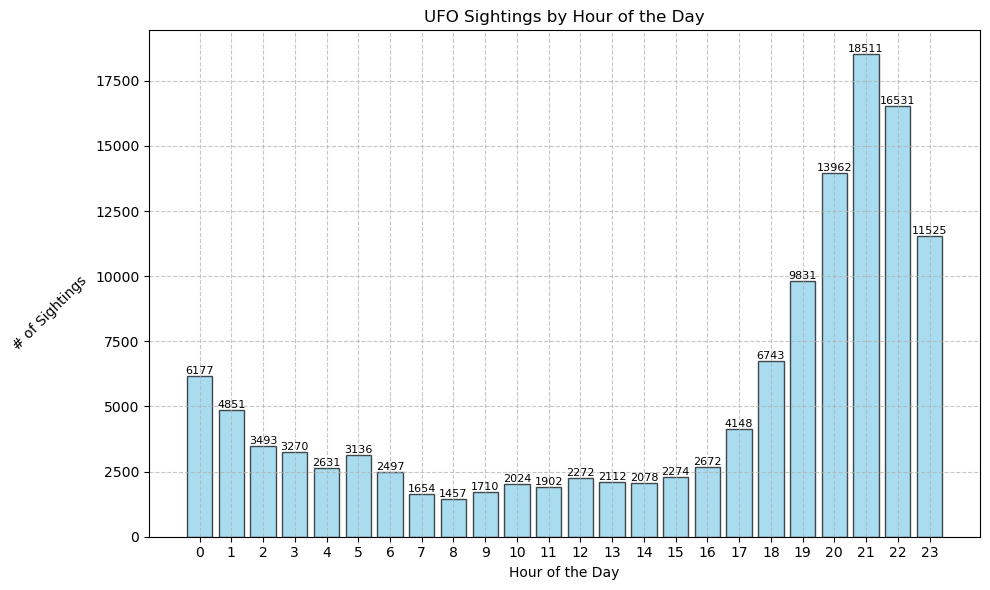

In [113]:
usa_ufo['hour'] = usa_ufo['datetime'].dt.hour

plt.figure(figsize=(10, 6))

sightings_by_hour = usa_ufo.groupby('hour')['hour'].count()
plt.bar(sightings_by_hour.index, sightings_by_hour.values, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('# of Sightings', rotation = 45, ha = 'right')
plt.title('UFO Sightings by Hour of the Day')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.7)

for i, v in enumerate(sightings_by_hour.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()

plt.show()

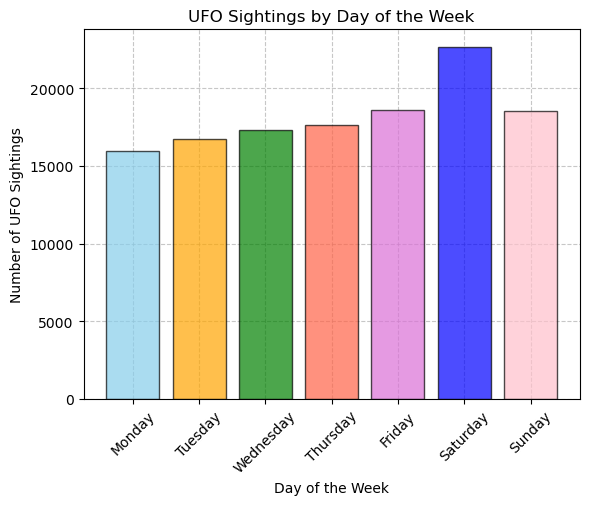

In [128]:
usa_ufo['day_of_week'] = usa_ufo['DateTime'].dt.day_name()

sightings_by_day = usa_ufo['day_of_week'].value_counts()

days_of_week_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sightings_by_day = sightings_by_day.reindex(days_of_week_ordered)
color_palette = ['skyblue', 'orange', 'green', 'tomato', 'orchid', 'blue', 'pink']

plt.bar(sightings_by_day.index, sightings_by_day.values, edgecolor='black', alpha=0.7, color = color_palette)
plt.xlabel('Day of the Week')
plt.ylabel('Number of UFO Sightings')
plt.title('UFO Sightings by Day of the Week')
plt.xticks(rotation=45)

plt.gca().set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [121]:
usa_ufo

,City,State,Country,Shape,Duration,Summary,Date,Time,Month,day_of_week,hour,DateTime
datetime,,,,,,,,,,,,
2016-11-01 18:30:00,PHIL CAMPBELL,AL,USA,Sphere,3 minutes,Light in sky.,2016-11-01,18:30:00,11,1,18,2016-11-01 18:30:00
2003-01-10 22:00:00,CULLMAN,AL,USA,Diamond,10 minutes,orange fireball in cull. al.,2003-01-10,22:00:00,1,4,22,2003-01-10 22:00:00
2014-04-13 21:00:00,HUNTSVILLE,AL,USA,Sphere,2 minutes,Orange orb seen.,2014-04-13,21:00:00,4,6,21,2014-04-13 21:00:00
2010-05-17 22:20:00,GRANT,AL,USA,Egg,10-15 mins,"2 Teardrop shaped crafts sighted, one followed...",2010-05-17,22:20:00,5,0,22,2010-05-17 22:20:00
2014-08-11 21:00:00,CORDOVA,AL,USA,Light,10 seconds,Flash the disappear. ((NUFORC Note: Possible t...,2014-08-11,21:00:00,8,0,21,2014-08-11 21:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-05-11 01:00:00,GLENDO (15 MILES S OF; I-25),WY,USA,Triangle,5 minutes,Driving north 15 miles before Glendo on I-25 I...,2018-05-11,01:00:00,5,4,1,2018-05-11 01:00:00
1999-06-20 23:00:00,LARAMIE (25 MILES NORTH OF),WY,USA,Unknown,3 sec,one group of three to the west followed by one...,1999-06-20,23:00:00,6,6,23,1999-06-20 23:00:00
2004-03-19 23:15:00,CHEYENNE,WY,USA,Other,2-3 Seconds,Green Streaking Object,2004-03-19,23:15:00,3,4,23,2004-03-19 23:15:00


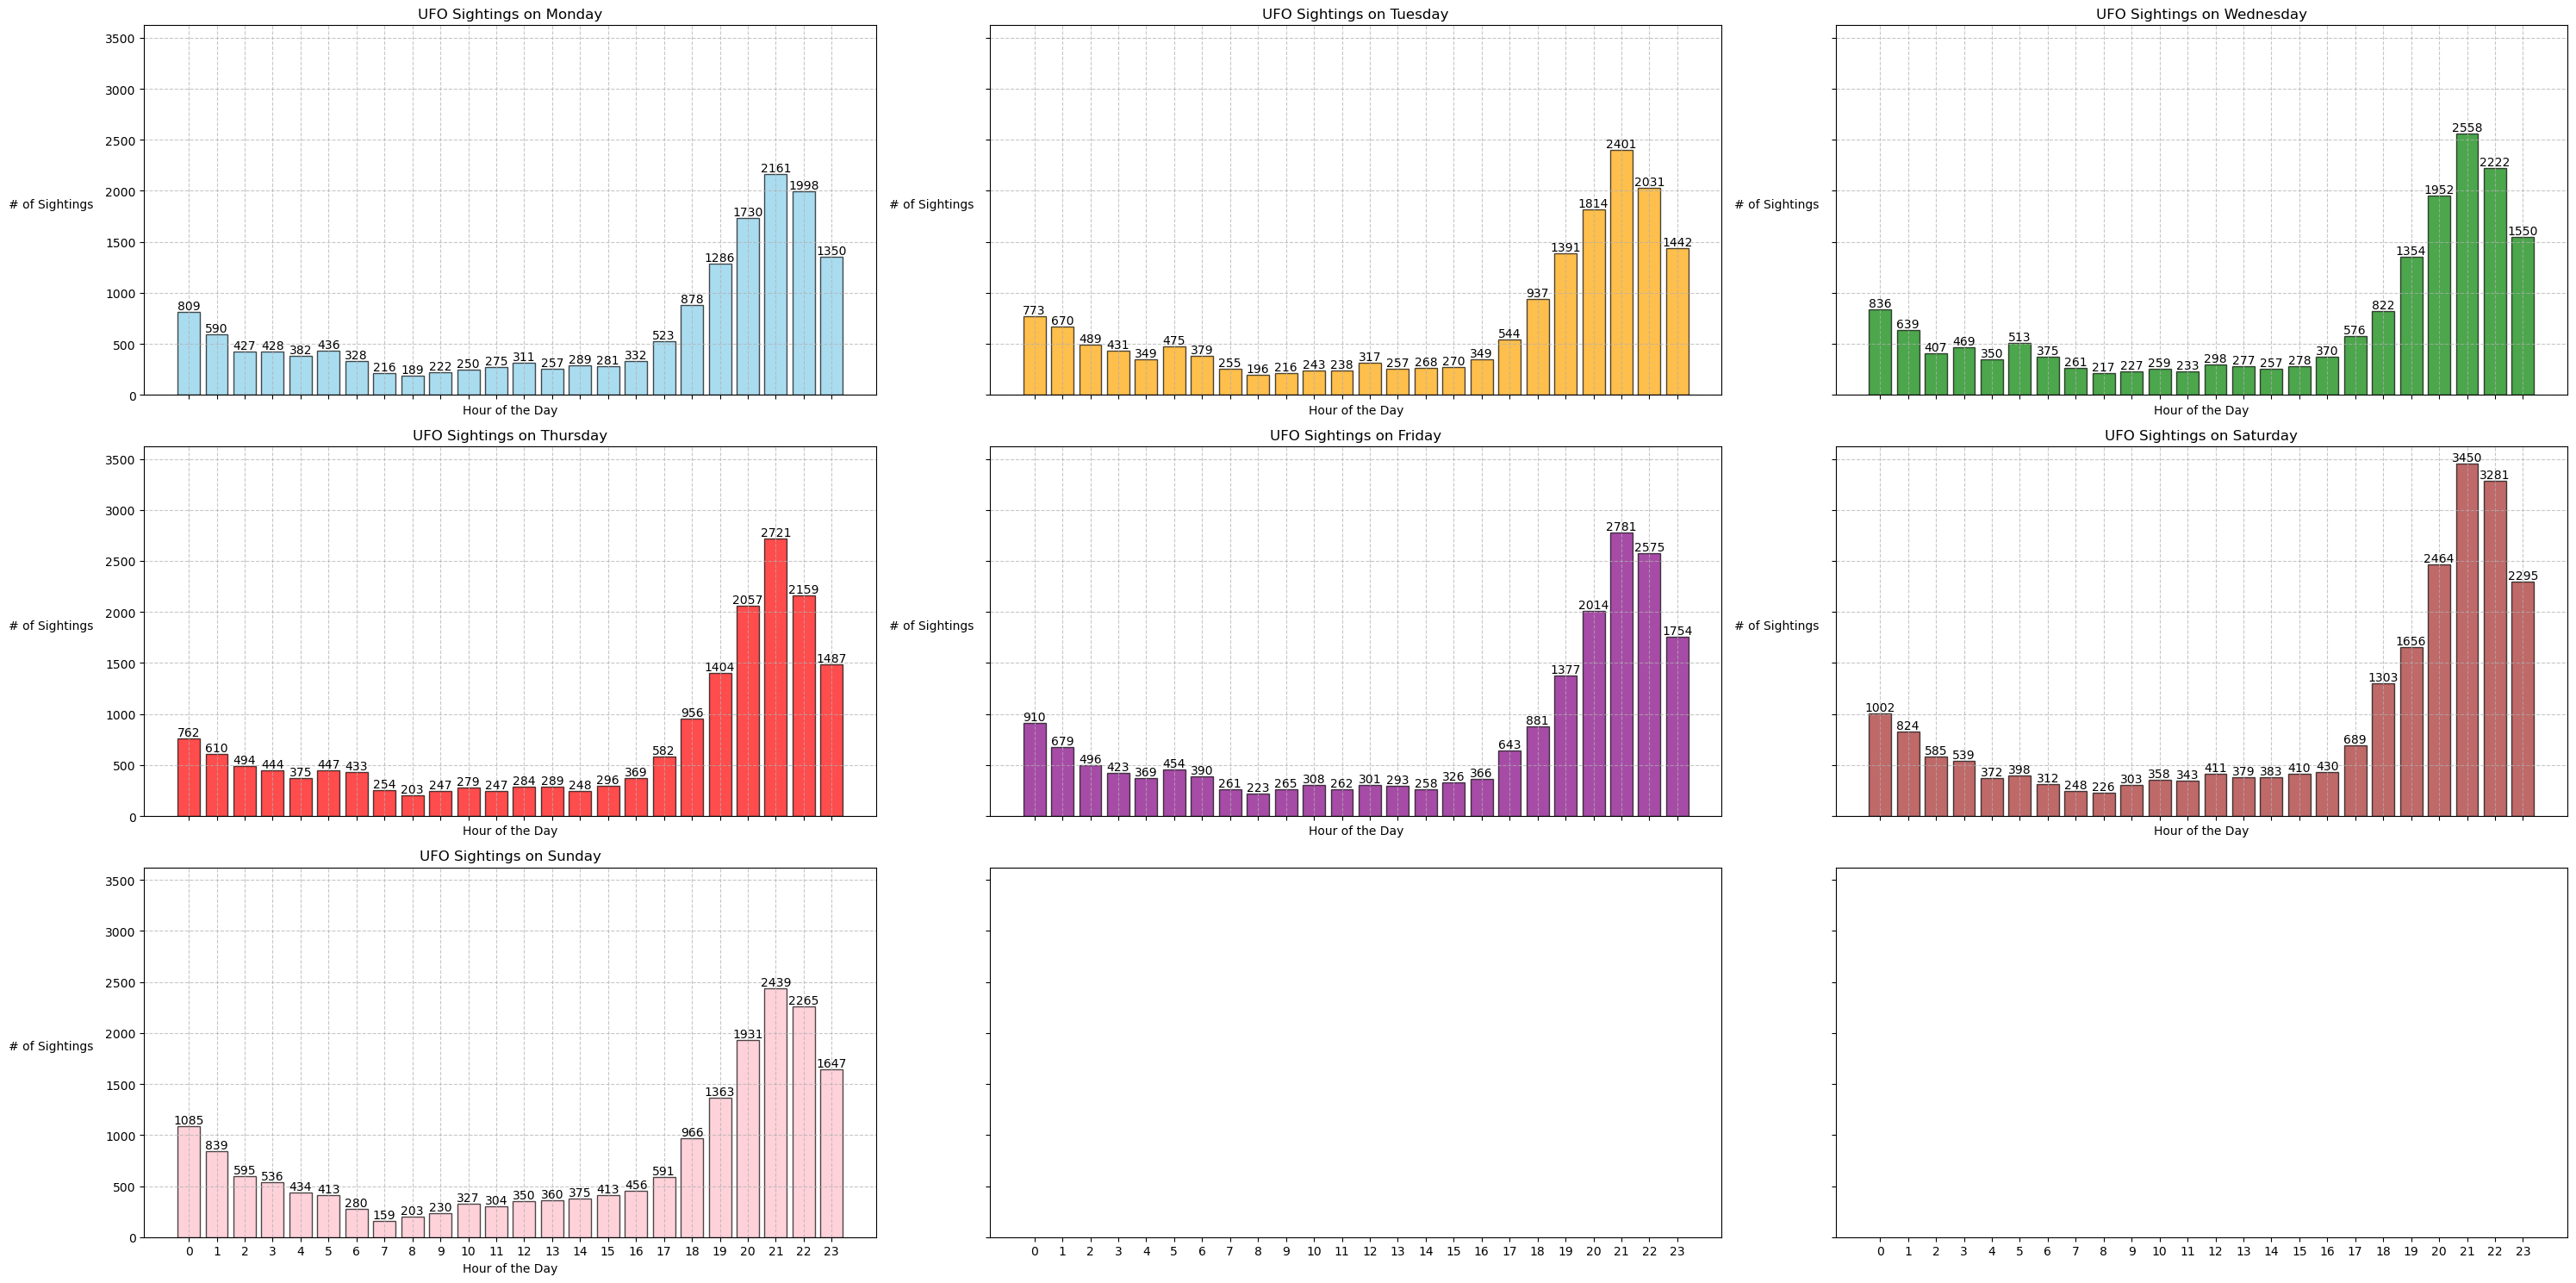

In [112]:
#make it pretty
color_palette = ['skyblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
fig, axs = plt.subplots(3, 3, figsize=(30, 15), sharex=True, sharey=True)

for day, ax in zip(range(7), axs.flatten()):
    sightings_by_hour = usa_ufo[usa_ufo['day_of_week'] == day]['hour'].value_counts().sort_index()
    ax.bar(sightings_by_hour.index, sightings_by_hour.values, color=color_palette[day], edgecolor='black', alpha=0.7, width=0.8)
    ax.set_xlabel('Hour of the Day')
    ax.set_title(f'UFO Sightings on {days_of_week_ordered[day]}')
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylabel('# of Sightings', rotation=0, labelpad=10, ha='right')

    # add number on bars
    for i, v in enumerate(sightings_by_hour.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()

plt.show()

/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1995539295.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(days_of_week_ordered, rotation=45)
/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1995539295.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(days_of_week_ordered, rotation=45)
/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1995539295.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(days_of_week_ordered, rotation=45)
/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1995539295.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(days_of_week_ordered, rotation=45)
/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1995539295.py:13: UserWarning: FixedFormatter should only be used together with

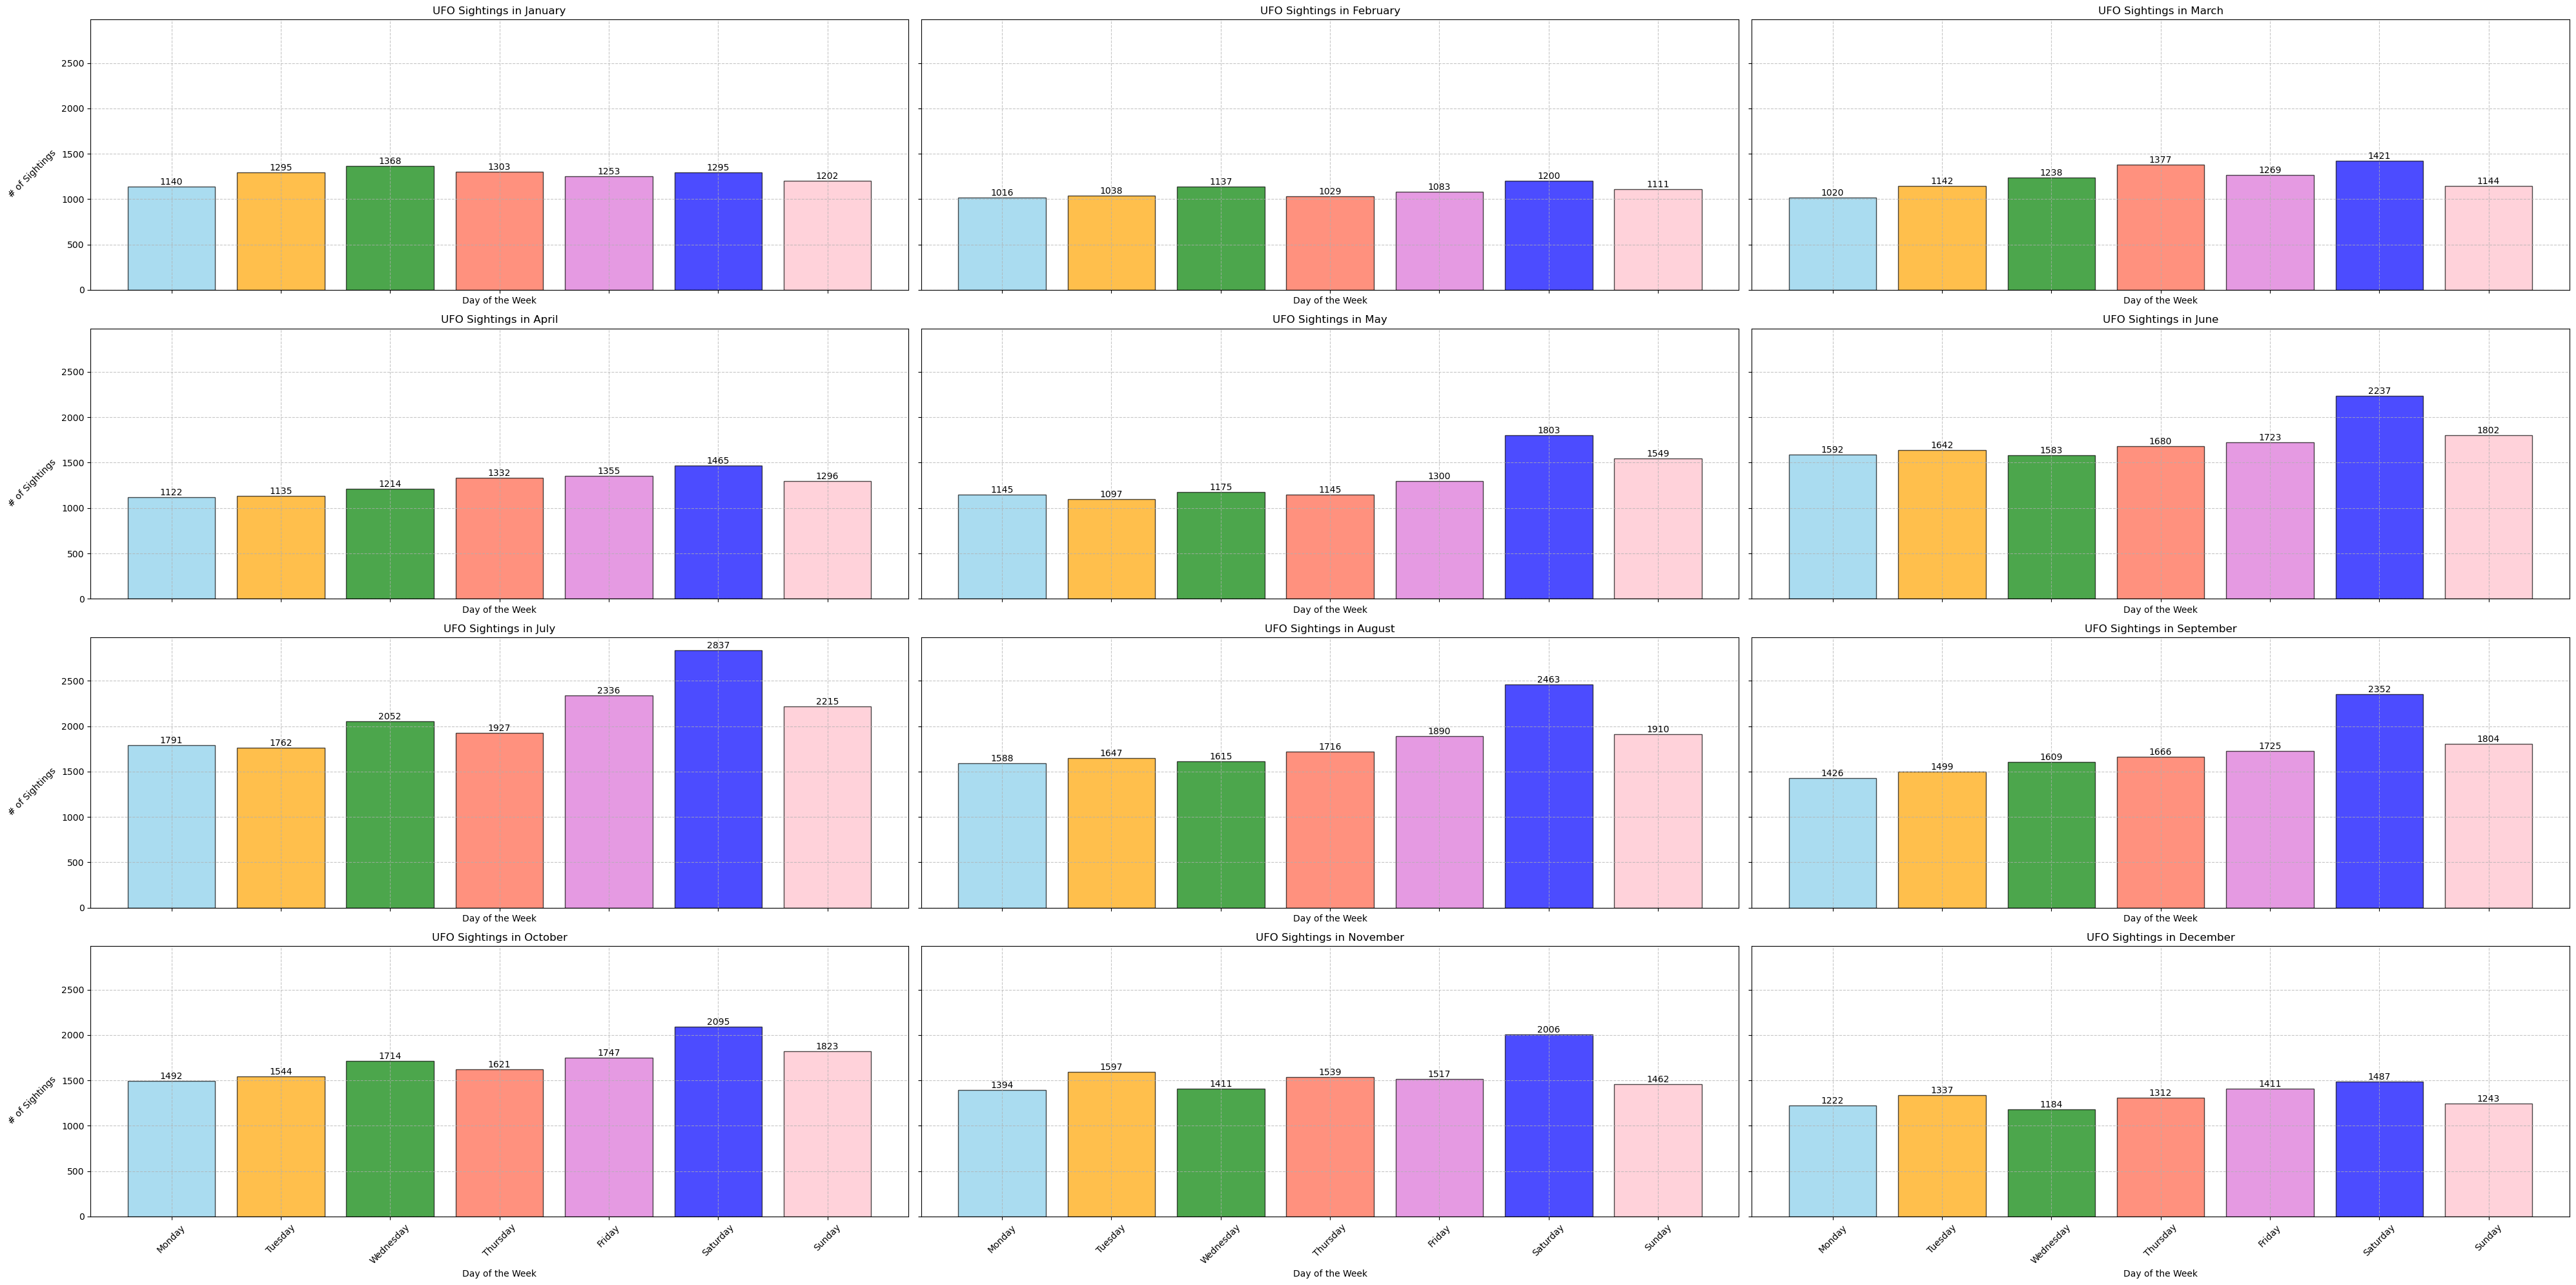

In [105]:
#days of the week of sightings by month

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

fig, axs = plt.subplots(4, 3, figsize=(40, 20), sharex=True, sharey=True)

for month, ax in zip(range(1, 13), axs.flat):
    sightings_by_month = usa_ufo[usa_ufo['Date'].dt.month == month]['day_of_week'].value_counts().reindex(days_of_week_ordered)
    ax.bar(days_of_week_ordered, sightings_by_month.values, edgecolor='black', alpha=0.7, color=color_palette)
    ax.set_xlabel('Day of the Week')
    ax.set_title(f'UFO Sightings in {month_names[month-1]}')
    ax.set_xticklabels(days_of_week_ordered, rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)

    for i, v in enumerate(sightings_by_month.values):
        ax.text(i, v, str(v), ha='center', va='bottom')

    if month % 3 == 1:
        ax.set_ylabel('# of Sightings', rotation=45, ha='right')

plt.tight_layout()
plt.show()

/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/1178189532.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_palette = plt.cm.get_cmap('tab20', len(month_names))


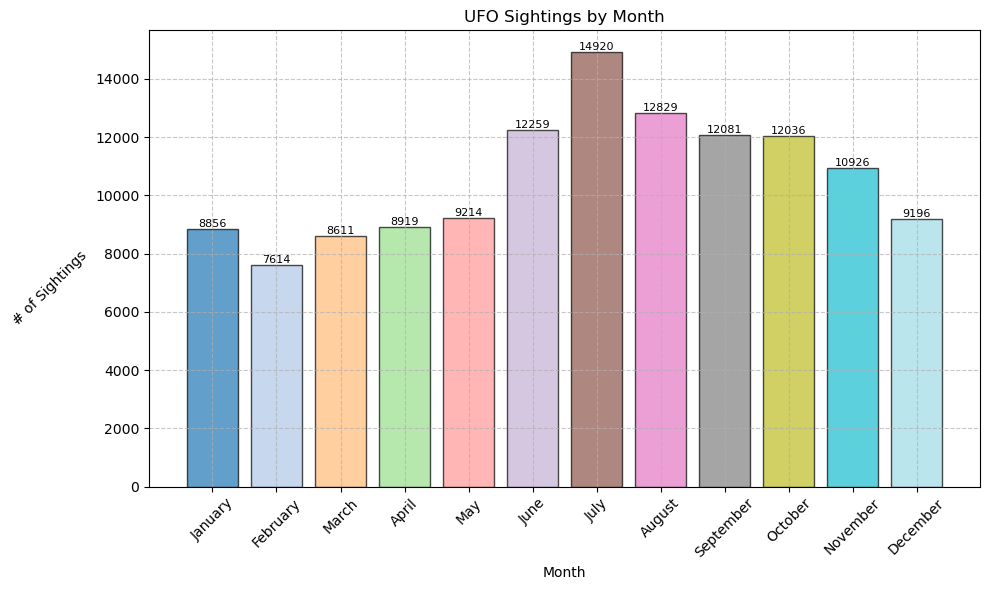

In [114]:
# color for months
color_palette = plt.cm.get_cmap('tab20', len(month_names))
plt.figure(figsize=(10, 6))

sightings_by_month = usa_ufo['Month'].value_counts().sort_index()
plt.bar(sightings_by_month.index, sightings_by_month.values, color=color_palette(range(len(month_names))), edgecolor='black', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('# of Sightings', rotation = 45, ha = 'right')
plt.title('UFO Sightings by Month')
plt.xticks(range(1, 13), month_names, rotation=45)

plt.tick_params(axis='y', rotation=0)

plt.grid(True, linestyle='--', alpha=0.7)

for i, v in enumerate(sightings_by_month.values):
    plt.text(i + 1, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()

plt.show()

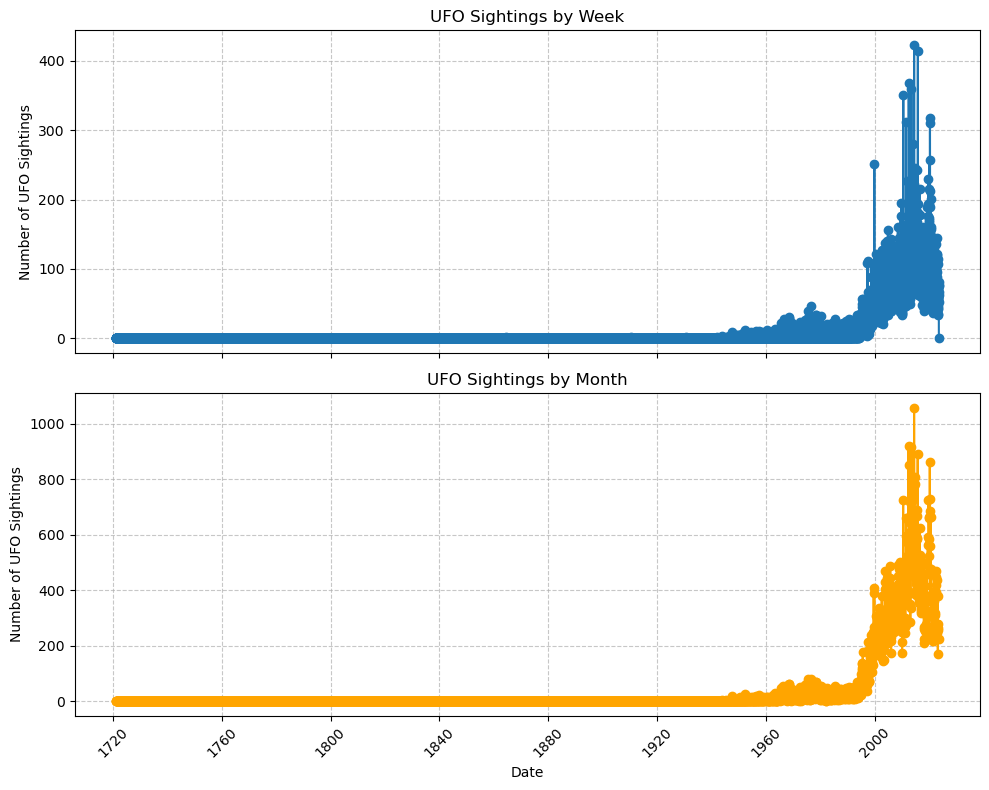

In [116]:
usa_ufo.set_index('datetime', inplace=True)
ufo_weekly = usa_ufo.resample('7D').size()
ufo_monthly = usa_ufo.resample('30D').size()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(ufo_weekly.index, ufo_weekly.values, marker='o')
ax1.set_ylabel('Number of UFO Sightings')
ax1.set_title('UFO Sightings by Week')
ax1.grid(True, linestyle='--', alpha=0.7)


ax2.plot(ufo_monthly.index, ufo_monthly.values, marker='o', color='orange')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of UFO Sightings')
ax2.set_title('UFO Sightings by Month')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Geographic Variation in UFO Sightings (Maria)
#### How do UFO sightings vary across states?
#### Within these states, how do the characteristics of sightings (such as shape and duration) vary?
#### Are certain cities or regions associated with specific types of sightings or patterns of activity?


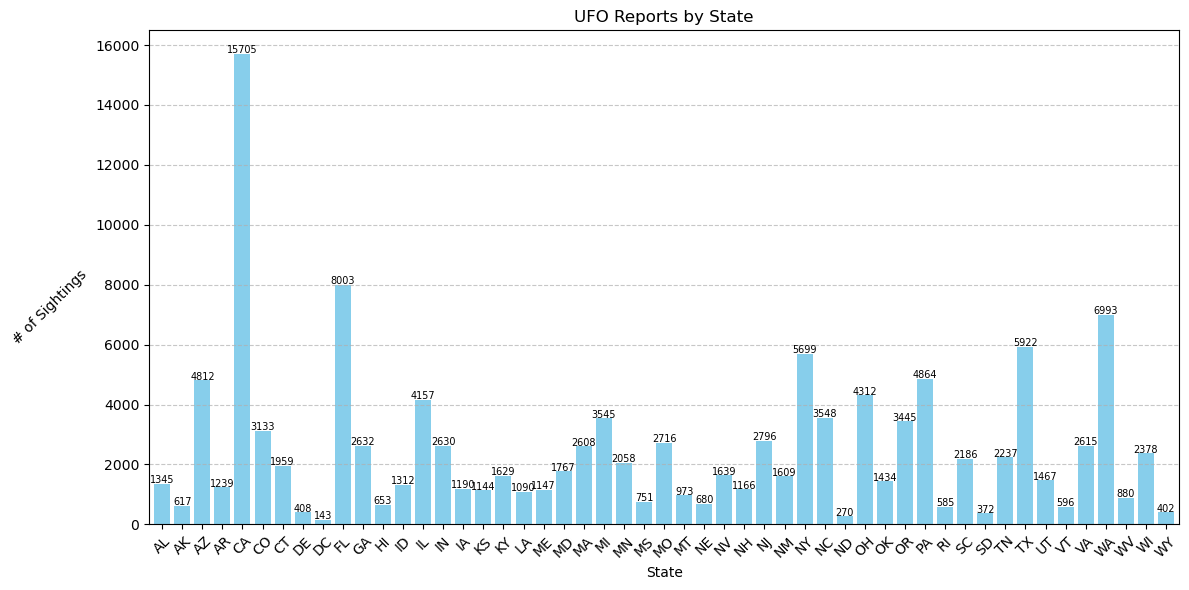

In [129]:
reports_by_state = usa_ufo['State'].value_counts()

desired_order = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 'ID', 'IL',
                'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE',
                'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD',
                'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

reports_by_state = reports_by_state.reindex(desired_order)

plt.figure(figsize=(12, 6))
ax = reports_by_state.plot(kind='bar', color='skyblue', width = 0.8)
plt.title('UFO Reports by State')
plt.xlabel('State')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='center')

plt.ylabel('# of Sightings', rotation= 45, ha='right')

for i, v in enumerate(reports_by_state):
    ax.text(i, v + 20, str(v), ha='center', fontsize=7)

plt.grid(axis='y', linestyle='--', alpha=0.7)    
plt.tight_layout()
plt.show()

In [130]:
reports_in_ca = reports_by_state['CA']
total_reports = len(usa_ufo)
percentage_in_ca = (reports_in_ca / total_reports) * 100

print(f"The percentage of UFO reports in California (CA) is: {percentage_in_ca:.2f}%")

The percentage of UFO reports in California (CA) is: 12.32%


In [131]:
total_reports_by_state = reports_by_state.sum()

state_percentages = (reports_by_state / total_reports_by_state) * 100
for state, percentage in state_percentages.items():
    print(f"The percentage of UFO reports in {state} is: {percentage:.2f}%")

The percentage of UFO reports in AL is: 1.06%
The percentage of UFO reports in AK is: 0.48%
The percentage of UFO reports in AZ is: 3.78%
The percentage of UFO reports in AR is: 0.97%
The percentage of UFO reports in CA is: 12.32%
The percentage of UFO reports in CO is: 2.46%
The percentage of UFO reports in CT is: 1.54%
The percentage of UFO reports in DE is: 0.32%
The percentage of UFO reports in DC is: 0.11%
The percentage of UFO reports in FL is: 6.28%
The percentage of UFO reports in GA is: 2.06%
The percentage of UFO reports in HI is: 0.51%
The percentage of UFO reports in ID is: 1.03%
The percentage of UFO reports in IL is: 3.26%
The percentage of UFO reports in IN is: 2.06%
The percentage of UFO reports in IA is: 0.93%
The percentage of UFO reports in KS is: 0.90%
The percentage of UFO reports in KY is: 1.28%
The percentage of UFO reports in LA is: 0.86%
The percentage of UFO reports in ME is: 0.90%
The percentage of UFO reports in MD is: 1.39%
The percentage of UFO reports in 

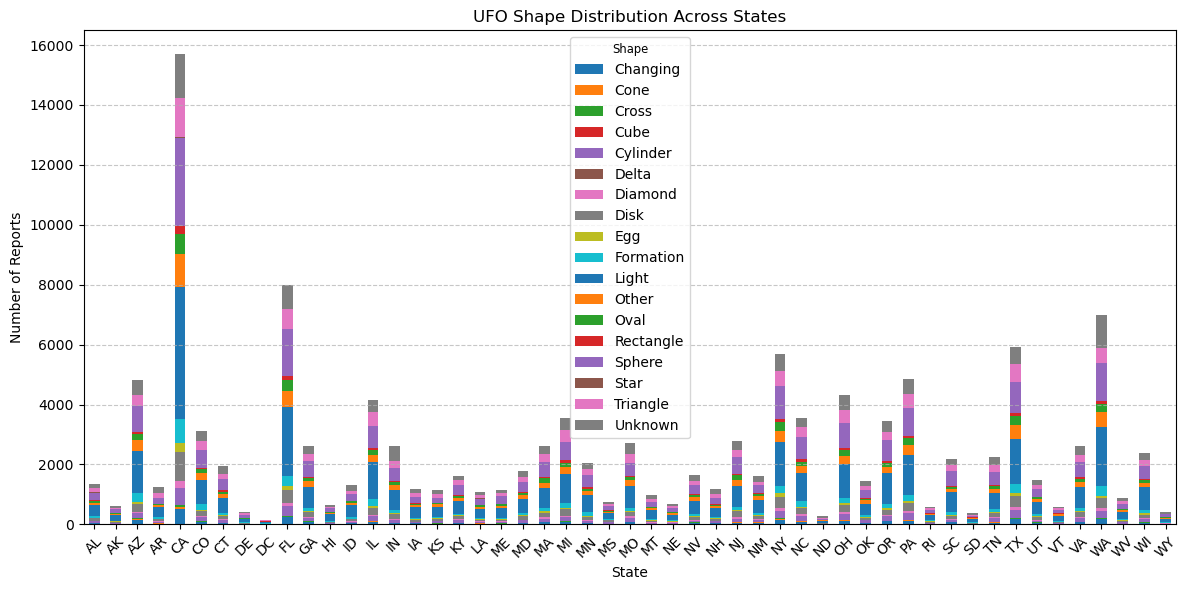

In [132]:
reports_by_state = usa_ufo['State'].value_counts()

shape_counts_by_state = usa_ufo.groupby(['State', 'Shape']).size().unstack(fill_value=0)

shape_counts_by_state.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('UFO Shape Distribution Across States')
plt.xlabel('State')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='center')
plt.legend(title='Shape', title_fontsize='small')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

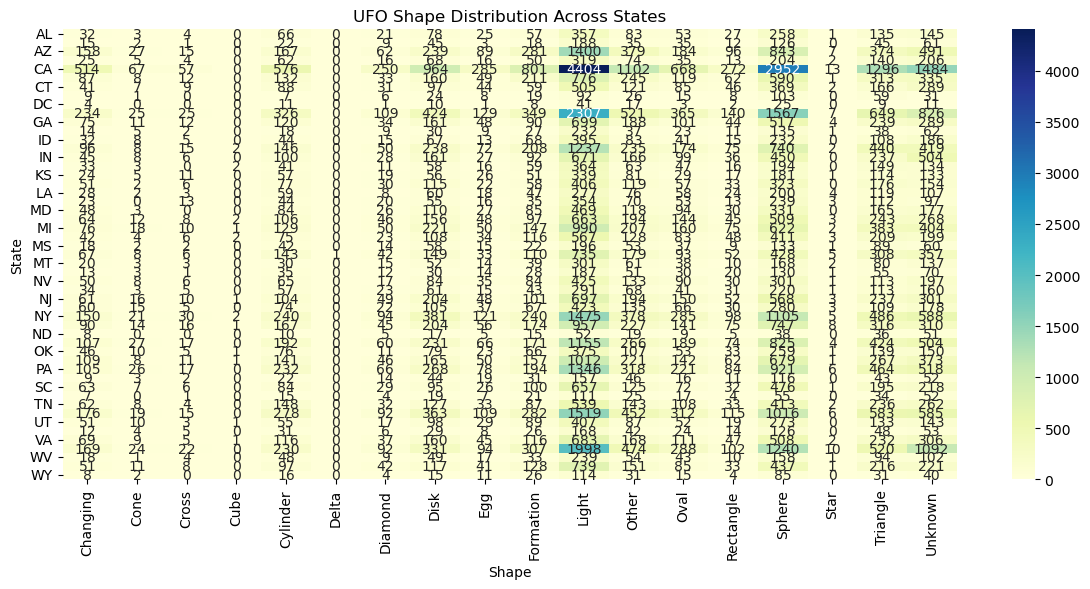

In [133]:
import seaborn as sns
shape_counts_by_state = usa_ufo.groupby(['State', 'Shape']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(shape_counts_by_state, cmap='YlGnBu', annot=True, fmt='d')
plt.title('UFO Shape Distribution Across States')
plt.xlabel('Shape')
plt.ylabel('State')

plt.tight_layout()
plt.show()

/var/folders/nj/tg_6sns90gqdc45lwr8v0zd40000gn/T/ipykernel_22809/364648534.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize= 15)


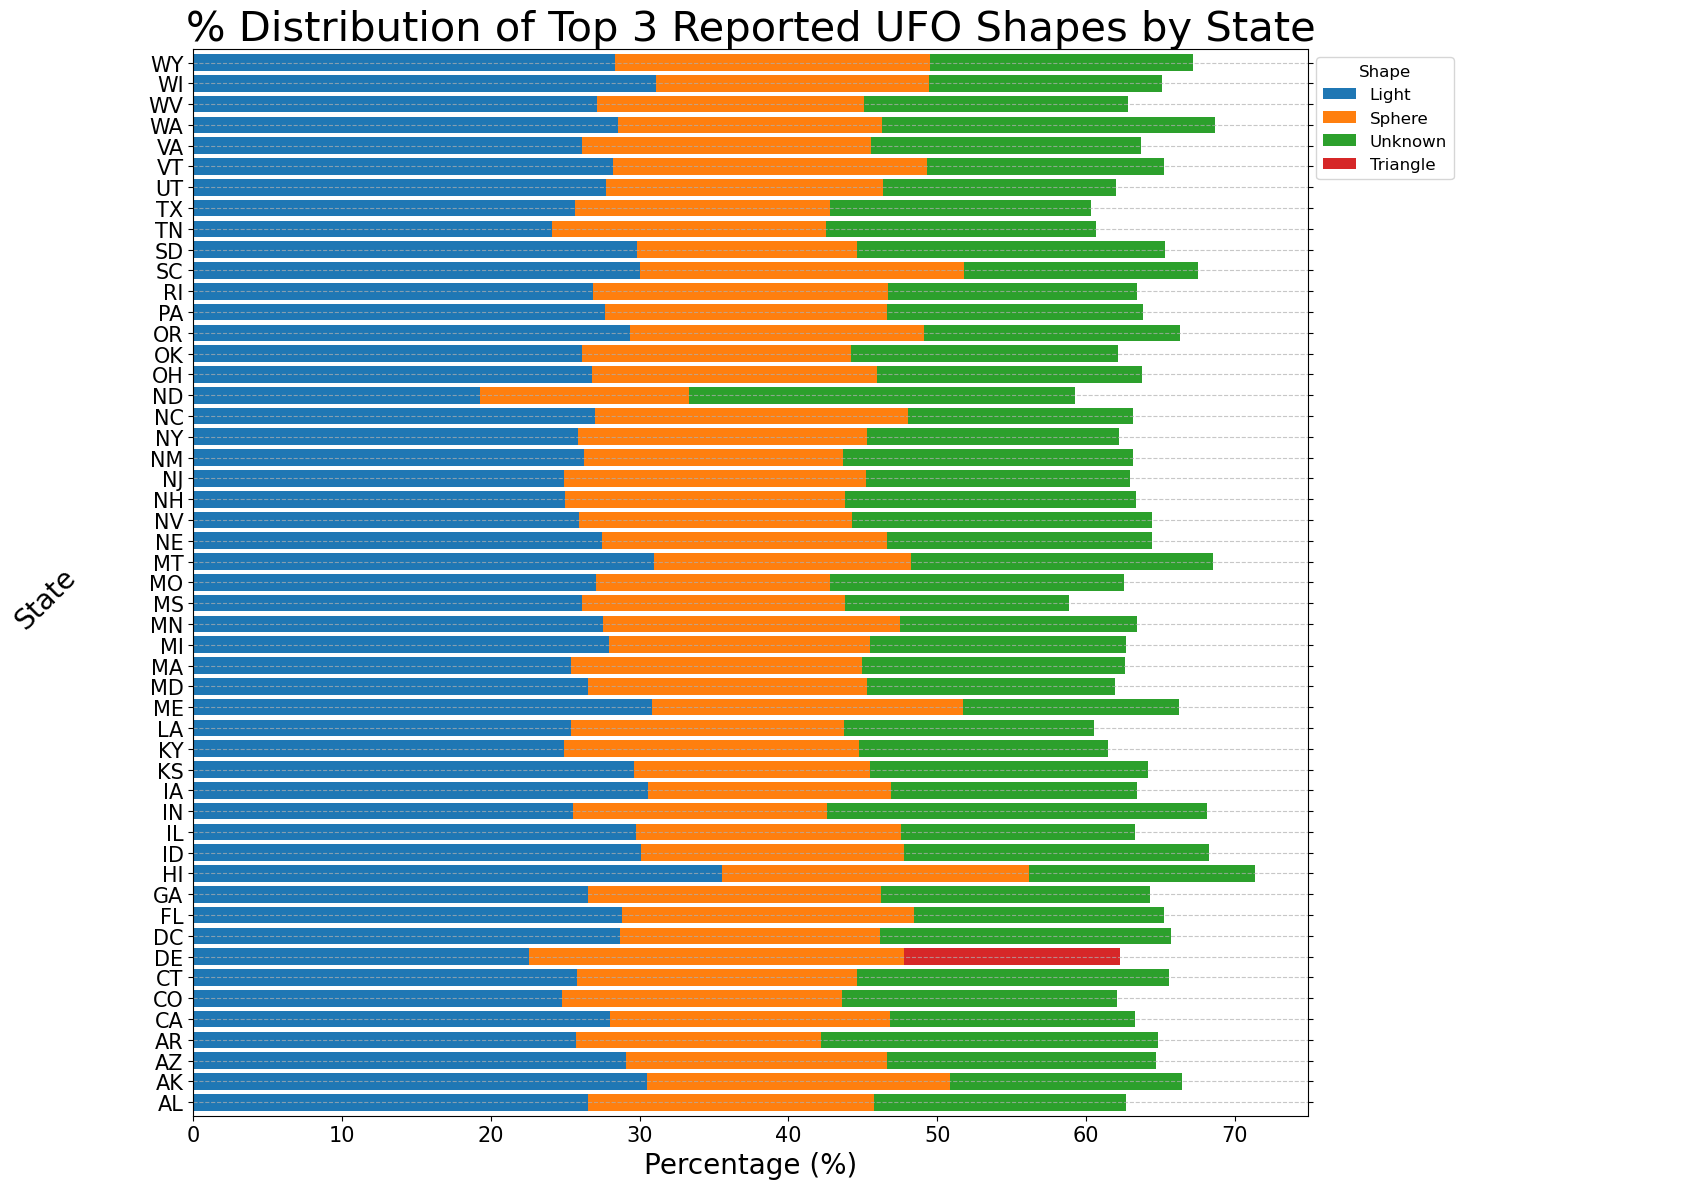

In [135]:
usa_ufo['Shape'] = usa_ufo['Shape'].replace('Other', 'Unknown')
top_shapes_by_state = usa_ufo.groupby('State')['Shape'].value_counts().groupby('State').head(3).unstack(fill_value=0)
total_reports_by_state = usa_ufo['State'].value_counts()
shape_percentage_by_state = (top_shapes_by_state.div(total_reports_by_state, axis=0) * 100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 12), gridspec_kw={'width_ratios': [5, 1]})

shape_percentage_by_state.plot(kind='barh', stacked=True, width=0.8, ax=ax1)
ax1.set_xlabel('Percentage (%)', fontsize= 20)
ax1.set_ylabel('State', rotation=45, ha='right', fontsize= 20)
ax1.set_title('% Distribution of Top 3 Reported UFO Shapes by State', fontsize= 30)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize= 15)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize= 15)
ax1.yaxis.tick_left()
ax1.yaxis.set_label_coords(-0.1, 0.5)
ax1.yaxis.set_ticks_position('both')
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

ax1.legend(title='Shape', title_fontsize='large', bbox_to_anchor=(1, 1), loc='upper left', fontsize = 12)
ax2.axis('off')

plt.tight_layout()
plt.show()

In [136]:
shape_percentage_by_state = usa_ufo.groupby(['State', 'Shape']).size() / usa_ufo.groupby('State').size() * 100
shape_percentage_by_state = shape_percentage_by_state.unstack(fill_value=0)
print(shape_percentage_by_state)

Shape  Changing      Cone     Cross      Cube  Cylinder     Delta   Diamond  \
State                                                                         
AL     2.379182  0.223048  0.297398  0.000000  4.907063  0.000000  1.561338   
AK     2.431118  0.324149  0.162075  0.000000  3.565640  0.000000  1.458671   
AZ     3.283458  0.561097  0.311721  0.000000  3.470490  0.000000  1.288446   
AR     2.017756  0.403551  0.322841  0.000000  5.004036  0.000000  1.291364   
CA     3.272843  0.426616  0.362942  0.000000  3.667622  0.000000  1.591850   
CO     2.776891  0.255346  0.383019  0.000000  4.213214  0.000000  1.053304   
CT     2.092905  0.357325  0.459418  0.000000  4.492088  0.000000  1.582440   
DE     2.205882  0.245098  0.000000  0.000000  1.715686  0.000000  1.470588   
DC     2.797203  0.000000  0.000000  0.000000  7.692308  0.000000  0.699301   
FL     2.923904  0.312383  0.312383  0.000000  4.073472  0.000000  1.361989   
GA     2.849544  0.417933  0.455927  0.000000  4.559

In [137]:
usa_ufo = pd.read_csv('UFO_summary_clean.csv')

In [138]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')  
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    words = word_tokenize(text)  #tokenize the text into words
    words = [word.lower() for word in words if word.isalpha()]  # remove non-alphabetic words
    words = [word for word in words if word not in stop_words]  # remove stop words
    return ' '.join(words)

usa_ufo['Cleaned_Summary'] = usa_ufo['Summary'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /Users/marialee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marialee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [139]:
usa_ufo['Cleaned_Summary']

0                                                 light sky
1                                   orange fireball cull al
2                                           orange orb seen
3         teardrop shaped crafts sighted one followed us...
4         flash disappear nuforc note possible tumbling ...
                                ...                        
110602    watching night sky one person spotted light ri...
110603    driving north miles glendo witnessed triangle ...
110604                               green streaking object
110605        multiple white soaring lights one section sky
110606        bright light nuforc note possible contrail pd
Name: Cleaned_Summary, Length: 110607, dtype: object

In [140]:
from collections import Counter
from nltk.stem import SnowballStemmer
import re

all_cleaned_summaries = ' '.join(usa_ufo['Cleaned_Summary'])
tokens = all_cleaned_summaries.split()
word_freq = Counter(tokens)
top_descriptive_words = word_freq.most_common(10)

print(top_descriptive_words)

[('lights', 26341), ('light', 25156), ('sky', 25127), ('bright', 19304), ('object', 18175), ('moving', 13660), ('white', 11653), ('orange', 10477), ('red', 10215), ('saw', 9699)]


In [141]:
all_cleaned_summaries = ' '.join(usa_ufo['Cleaned_Summary'])
tokens = all_cleaned_summaries.split()
stemmer = SnowballStemmer('english')
stemmed_tokens = [stemmer.stem(token) for token in tokens]
cleaned_tokens = [token for token in stemmed_tokens if re.match('^[a-zA-Z]+$', token)]
word_freq = Counter(cleaned_tokens)
top_descriptive_words = word_freq.most_common(10)

print(top_descriptive_words)

[('light', 52277), ('sky', 25612), ('object', 23909), ('bright', 19785), ('move', 18431), ('shape', 12019), ('white', 11668), ('orang', 10504), ('red', 10250), ('saw', 9701)]


In [142]:
cleaned_tokens = [token.replace('orang', 'orange') for token in cleaned_tokens]
cleaned_tokens = [token.replace('lights', 'light') for token in cleaned_tokens]
word_freq = Counter(cleaned_tokens)
top_descriptive_words = word_freq.most_common(10)

print(top_descriptive_words)

[('light', 52277), ('sky', 25612), ('object', 23909), ('bright', 19785), ('move', 18431), ('shape', 12019), ('white', 11668), ('orange', 10504), ('red', 10250), ('saw', 9701)]


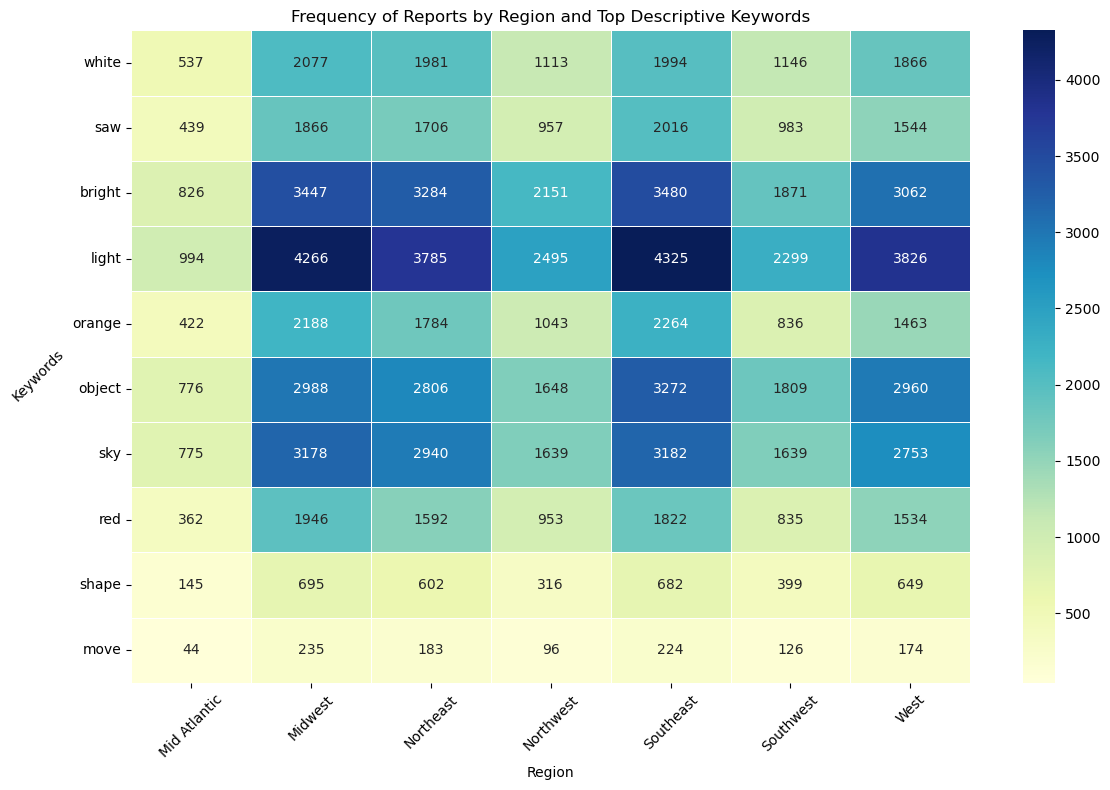

In [144]:
def extract_keywords(text):
    keywords = text.lower().split()
    return keywords

usa_ufo['Keywords'] = usa_ufo['Summary'].apply(extract_keywords)
top_descriptive_words = ['light', 'sky', 'object', 'bright', 'move', 'shape', 'white', 'orange', 'red', 'saw']

regions = {'Northwest': ['WA', 'OR', 'ID', 'MT', 'WY', 'AK'],
           'West': ['CA', 'NV', 'UT', 'CO'],
           'Southwest': ['AZ', 'NM', 'TX', 'OK'],
           'Midwest': ['ND', 'SD', 'NE', 'KS', 'MN', 'IA', 'MO', 'WI', 'IL', 'IN', 'MI', 'OH'],
           'Southeast': ['AR', 'LA', 'MS', 'AL', 'TN', 'KY', 'FL', 'GA', 'SC', 'NC'],
           'Mid Atlantic': ['WV', 'VA', 'MD', 'DE'],
           'Northeast': ['PA', 'NJ', 'NY', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME']}

def get_region(state):
    for region, states in regions.items():
        if state in states:
            return region
    return None

usa_ufo['Region'] = usa_ufo['State'].apply(get_region)

keywords_by_region = usa_ufo.groupby('Region')['Keywords'].sum()
keywords_by_region = keywords_by_region.apply(Counter)
keywords_by_region = keywords_by_region.apply(lambda x: {key: val for key, val in x.items() if key in top_descriptive_words})

keywords_df = keywords_by_region.apply(pd.Series).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(keywords_df.T, cmap='YlGnBu', annot=True, fmt='g', linewidths=0.5)
plt.xlabel('Region')
plt.ylabel('Keywords', rotation=45, ha='right')
plt.title('Frequency of Reports by Region and Top Descriptive Keywords')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()